In [2]:
import pandas as pd

inventory_df = pd.read_csv(
    r"C:\Users\Pawan\OneDrive\Desktop\Online-Retail-II\Online-retail-demand-forcasting\data1\raw\retail_clean_dataset\inventory_snapshot.csv"
)

print("Shape:", inventory_df.shape)
print("\nColumns:")
print(inventory_df.columns.tolist())

inventory_df.head()

Shape: (21228, 6)

Columns:
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,323,72,22,2025-05-17
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,433,96,34,2025-05-20
3,ST19,SKU02907,178,34,13,2025-08-03
4,ST05,SKU01023,333,97,22,2025-07-12


In [3]:
inventory_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21228 entries, 0 to 21227
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   store_id           21228 non-null  str  
 1   sku_id             21228 non-null  str  
 2   stock_on_hand      21228 non-null  int64
 3   reorder_point      21228 non-null  int64
 4   safety_stock       21228 non-null  int64
 5   last_restock_date  21228 non-null  str  
dtypes: int64(3), str(3)
memory usage: 1.4 MB


In [4]:
inventory_df['last_restock_date'] = pd.to_datetime(
    inventory_df['last_restock_date']
)

print(inventory_df.dtypes)

store_id                        str
sku_id                          str
stock_on_hand                 int64
reorder_point                 int64
safety_stock                  int64
last_restock_date    datetime64[us]
dtype: object


In [5]:
def get_stock_status(row):
    if row['stock_on_hand'] <= row['safety_stock']:
        return 'High Risk'
    elif row['stock_on_hand'] <= row['reorder_point']:
        return 'Medium Risk'
    else:
        return 'Low Risk'


inventory_df['risk_level'] = inventory_df.apply(
    get_stock_status,
    axis=1
)

inventory_df['risk_level'].value_counts()

risk_level
Low Risk       15366
High Risk       3888
Medium Risk     1974
Name: count, dtype: int64

In [6]:
inventory_df[
    ['store_id', 'sku_id', 'stock_on_hand',
     'reorder_point', 'safety_stock', 'risk_level']
].head(10)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,risk_level
0,ST11,SKU02558,323,72,22,Low Risk
1,ST21,SKU01031,236,67,14,Low Risk
2,ST26,SKU02129,433,96,34,Low Risk
3,ST19,SKU02907,178,34,13,Low Risk
4,ST05,SKU01023,333,97,22,Low Risk
5,ST08,SKU04475,470,90,29,Low Risk
6,ST01,SKU01318,125,24,9,Low Risk
7,ST13,SKU00389,212,49,15,Low Risk
8,ST25,SKU01675,259,77,32,Low Risk
9,ST06,SKU01396,204,57,12,Low Risk


In [7]:
print("Risk distribution:")
print(inventory_df['risk_level'].value_counts())

Risk distribution:
risk_level
Low Risk       15366
High Risk       3888
Medium Risk     1974
Name: count, dtype: int64


In [8]:
inventory_df['risk_score'] = 0

# High Risk
inventory_df.loc[
    inventory_df['risk_level'] == 'High Risk',
    'risk_score'
] = 100

# Medium Risk
inventory_df.loc[
    inventory_df['risk_level'] == 'Medium Risk',
    'risk_score'
] = 60

# Low Risk
inventory_df.loc[
    inventory_df['risk_level'] == 'Low Risk',
    'risk_score'
] = 20

inventory_df[
    ['store_id', 'sku_id', 'stock_on_hand',
     'reorder_point', 'safety_stock',
     'risk_level', 'risk_score']
].head(10)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,risk_level,risk_score
0,ST11,SKU02558,323,72,22,Low Risk,20
1,ST21,SKU01031,236,67,14,Low Risk,20
2,ST26,SKU02129,433,96,34,Low Risk,20
3,ST19,SKU02907,178,34,13,Low Risk,20
4,ST05,SKU01023,333,97,22,Low Risk,20
5,ST08,SKU04475,470,90,29,Low Risk,20
6,ST01,SKU01318,125,24,9,Low Risk,20
7,ST13,SKU00389,212,49,15,Low Risk,20
8,ST25,SKU01675,259,77,32,Low Risk,20
9,ST06,SKU01396,204,57,12,Low Risk,20


In [9]:
high_risk_inventory = inventory_df[
    inventory_df['risk_level'] == 'High Risk'
].sort_values(
    'stock_on_hand'
)

high_risk_inventory.head(20)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date,risk_level,risk_score
90,ST13,SKU00994,0,73,15,2025-09-01,High Risk,100
154,ST16,SKU01547,0,79,26,2025-10-01,High Risk,100
148,ST10,SKU00830,0,87,23,2025-08-31,High Risk,100
146,ST05,SKU02930,0,23,8,2025-09-12,High Risk,100
142,ST11,SKU00264,0,31,7,2025-08-21,High Risk,100
140,ST06,SKU04350,0,92,26,2025-08-16,High Risk,100
138,ST29,SKU04105,0,83,32,2025-09-25,High Risk,100
132,ST04,SKU02355,0,48,17,2025-10-10,High Risk,100
122,ST07,SKU01485,0,55,27,2025-08-07,High Risk,100
120,ST26,SKU02747,0,26,8,2025-09-02,High Risk,100


In [10]:
print(
    "High-risk inventory records:",
    len(high_risk_inventory)
)

High-risk inventory records: 3888


In [11]:
risk_by_store = (
    inventory_df
    .groupby(['store_id', 'risk_level'])
    .size()
    .unstack(fill_value=0)
)

risk_by_store.head()

risk_level,High Risk,Low Risk,Medium Risk
store_id,,,
ST01,133,508,79
ST02,107,512,61
ST03,148,533,66
ST04,144,505,62
ST05,116,537,61


In [12]:
risk_by_store['Total'] = risk_by_store.sum(axis=1)

risk_by_store.sort_values(
    'High Risk',
    ascending=False
).head(10)

risk_level,High Risk,Low Risk,Medium Risk,Total
store_id,,,,
ST03,148,533,66,747
ST10,145,526,59,730
ST04,144,505,62,711
ST27,142,496,52,690
ST25,142,508,56,706
ST12,140,510,62,712
ST24,140,492,63,695
ST16,137,521,61,719
ST11,136,507,74,717


In [13]:
sales_df = pd.read_csv(
    r"c:\Users\Pawan\OneDrive\Desktop\Online-Retail-II\Online-retail-demand-forcasting\data\processed\sales_transactions_cleaned.csv"
)

print(sales_df.shape)

(9959019, 12)


In [14]:
sku_demand = (
    sales_df
    .groupby('sku_id')['quantity']
    .sum()
    .reset_index(name='total_demand')
)

sku_demand.head()

,sku_id,total_demand
0,SKU00001,4771
1,SKU00002,38506
2,SKU00003,1325
3,SKU00004,2534
4,SKU00005,2292


In [15]:
sales_df['date'] = pd.to_datetime(sales_df['date'])

days = (
    sales_df['date'].max() -
    sales_df['date'].min()
).days + 1

print("Number of days:", days)

Number of days: 1461


In [16]:
sku_demand['avg_daily_demand'] = (
    sku_demand['total_demand'] / days
)

sku_demand.head()

,sku_id,total_demand,avg_daily_demand
0,SKU00001,4771,3.265572
1,SKU00002,38506,26.355921
2,SKU00003,1325,0.906913
3,SKU00004,2534,1.734428
4,SKU00005,2292,1.568789


In [17]:
inventory_df = inventory_df.merge(
    sku_demand[['sku_id', 'avg_daily_demand']],
    on='sku_id',
    how='left'
)

inventory_df.head()

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date,risk_level,risk_score,avg_daily_demand
0,ST11,SKU02558,323,72,22,2025-05-17,Low Risk,20,0.853525
1,ST21,SKU01031,236,67,14,2025-06-17,Low Risk,20,0.814511
2,ST26,SKU02129,433,96,34,2025-05-20,Low Risk,20,0.869268
3,ST19,SKU02907,178,34,13,2025-08-03,Low Risk,20,0.870637
4,ST05,SKU01023,333,97,22,2025-07-12,Low Risk,20,0.917180


In [18]:
inventory_df['stock_coverage_days'] = (
    inventory_df['stock_on_hand'] /
    inventory_df['avg_daily_demand']
)

inventory_df[
    ['store_id', 'sku_id', 'stock_on_hand',
     'avg_daily_demand', 'stock_coverage_days',
     'risk_level']
].head(10)

,store_id,sku_id,stock_on_hand,avg_daily_demand,stock_coverage_days,risk_level
0,ST11,SKU02558,323,0.853525,378.430634,Low Risk
1,ST21,SKU01031,236,0.814511,289.744538,Low Risk
2,ST26,SKU02129,433,0.869268,498.120472,Low Risk
3,ST19,SKU02907,178,0.870637,204.448113,Low Risk
4,ST05,SKU01023,333,0.917180,363.069403,Low Risk
5,ST08,SKU04475,470,0.869952,540.259638,Low Risk
6,ST01,SKU01318,125,0.835044,149.692623,Low Risk
7,ST13,SKU00389,212,0.915127,231.661930,Low Risk
8,ST25,SKU01675,259,0.850787,304.423974,Low Risk
9,ST06,SKU01396,204,0.856263,238.244604,Low Risk


In [19]:
store_sku_demand = (
    sales_df
    .groupby(['store_id', 'sku_id'])['quantity']
    .sum()
    .reset_index(name='total_demand')
)

store_sku_demand.head()

,store_id,sku_id,total_demand
0,ST01,SKU00001,107
1,ST01,SKU00002,963
2,ST01,SKU00003,29
3,ST01,SKU00004,67
4,ST01,SKU00005,66


In [20]:
store_sku_demand['avg_daily_demand'] = (
    store_sku_demand['total_demand'] / days
)

store_sku_demand.head()

,store_id,sku_id,total_demand,avg_daily_demand
0,ST01,SKU00001,107,0.073238
1,ST01,SKU00002,963,0.659138
2,ST01,SKU00003,29,0.019849
3,ST01,SKU00004,67,0.045859
4,ST01,SKU00005,66,0.045175


In [21]:
inventory_df = inventory_df.drop(
    columns=['avg_daily_demand']
)

In [22]:
inventory_df = inventory_df.merge(
    store_sku_demand[
        ['store_id', 'sku_id', 'avg_daily_demand']
    ],
    on=['store_id', 'sku_id'],
    how='left'
)

inventory_df.head()

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date,risk_level,risk_score,stock_coverage_days,avg_daily_demand
0,ST11,SKU02558,323,72,22,2025-05-17,Low Risk,20,378.430634,0.032854
1,ST21,SKU01031,236,67,14,2025-06-17,Low Risk,20,289.744538,0.054073
2,ST26,SKU02129,433,96,34,2025-05-20,Low Risk,20,498.120472,0.008898
3,ST19,SKU02907,178,34,13,2025-08-03,Low Risk,20,204.448113,0.023272
4,ST05,SKU01023,333,97,22,2025-07-12,Low Risk,20,363.069403,0.028747


In [23]:
inventory_df['stock_coverage_days'] = (
    inventory_df['stock_on_hand'] /
    inventory_df['avg_daily_demand']
)

In [24]:
inventory_df[
    ['store_id', 'sku_id',
     'stock_on_hand',
     'avg_daily_demand',
     'stock_coverage_days',
     'risk_level']
].sort_values(
    'stock_coverage_days'
).head(20)

,store_id,sku_id,stock_on_hand,avg_daily_demand,stock_coverage_days,risk_level
3931,ST04,SKU00484,0,0.489391,0.0,High Risk
16,ST16,SKU01037,0,0.451745,0.0,High Risk
12,ST01,SKU00500,0,0.387406,0.0,High Risk
5185,ST26,SKU02776,0,0.228611,0.0,High Risk
5176,ST16,SKU02381,0,0.205339,0.0,High Risk
5151,ST04,SKU00974,0,0.379192,0.0,High Risk
5280,ST04,SKU00774,0,0.555784,0.0,High Risk
44,ST28,SKU04551,0,0.778234,0.0,High Risk
36,ST01,SKU03546,0,0.364134,0.0,High Risk
22,ST08,SKU02381,0,0.303217,0.0,High Risk


In [25]:
def calculate_risk_score(row):
    coverage = row['stock_coverage_days']

    if row['stock_on_hand'] == 0:
        return 100
    elif coverage <= 7:
        return 90
    elif coverage <= 14:
        return 70
    elif coverage <= 30:
        return 50
    elif row['stock_on_hand'] <= row['reorder_point']:
        return 40
    else:
        return 20


inventory_df['risk_score'] = inventory_df.apply(
    calculate_risk_score,
    axis=1
)

In [26]:
def get_final_risk(score):
    if score >= 90:
        return 'Critical'
    elif score >= 70:
        return 'High Risk'
    elif score >= 40:
        return 'Medium Risk'
    else:
        return 'Low Risk'


inventory_df['final_risk_level'] = (
    inventory_df['risk_score'].apply(get_final_risk)
)

In [27]:
inventory_df['final_risk_level'].value_counts()

final_risk_level
Low Risk       15363
Medium Risk     3012
Critical        2823
High Risk         30
Name: count, dtype: int64

In [28]:
critical_inventory = (
    inventory_df[
        inventory_df['final_risk_level'] == 'Critical'
    ]
    .sort_values(
        ['stock_on_hand', 'stock_coverage_days']
    )
)

critical_inventory[
    [
        'store_id',
        'sku_id',
        'stock_on_hand',
        'reorder_point',
        'safety_stock',
        'avg_daily_demand',
        'stock_coverage_days',
        'risk_score',
        'final_risk_level'
    ]
].head(20)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,avg_daily_demand,stock_coverage_days,risk_score,final_risk_level
12,ST01,SKU00500,0,54,24,0.387406,0.0,100,Critical
16,ST16,SKU01037,0,92,38,0.451745,0.0,100,Critical
17,ST21,SKU01152,0,76,32,0.644764,0.0,100,Critical
22,ST08,SKU02381,0,36,15,0.303217,0.0,100,Critical
36,ST01,SKU03546,0,42,18,0.364134,0.0,100,Critical
44,ST28,SKU04551,0,80,39,0.778234,0.0,100,Critical
58,ST15,SKU02747,0,100,30,0.485969,0.0,100,Critical
62,ST06,SKU04913,0,26,9,0.865161,0.0,100,Critical
63,ST04,SKU04315,0,76,24,0.352498,0.0,100,Critical
65,ST26,SKU00169,0,23,9,0.430527,0.0,100,Critical


In [29]:
def calculate_risk_score(row):
    coverage = row['stock_coverage_days']

    if row['stock_on_hand'] == 0 or coverage <= 3:
        return 100
    elif coverage <= 7:
        return 80
    elif coverage <= 14:
        return 60
    else:
        return 20


inventory_df['risk_score'] = inventory_df.apply(
    calculate_risk_score,
    axis=1
)

In [30]:
def get_final_risk(score):
    if score == 100:
        return 'Critical'
    elif score == 80:
        return 'High Risk'
    elif score == 60:
        return 'Medium Risk'
    else:
        return 'Low Risk'


inventory_df['final_risk_level'] = (
    inventory_df['risk_score'].apply(get_final_risk)
)

print(inventory_df['final_risk_level'].value_counts())

final_risk_level
Low Risk       18375
Critical        2815
Medium Risk       30
High Risk          8
Name: count, dtype: int64


In [31]:
critical_inventory = (
    inventory_df[
        inventory_df['final_risk_level'] == 'Critical'
    ]
    .sort_values(
        ['stock_on_hand', 'stock_coverage_days']
    )
)

critical_inventory[
    [
        'store_id',
        'sku_id',
        'stock_on_hand',
        'reorder_point',
        'safety_stock',
        'avg_daily_demand',
        'stock_coverage_days',
        'risk_score',
        'final_risk_level'
    ]
].head(20)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,avg_daily_demand,stock_coverage_days,risk_score,final_risk_level
12,ST01,SKU00500,0,54,24,0.387406,0.0,100,Critical
16,ST16,SKU01037,0,92,38,0.451745,0.0,100,Critical
17,ST21,SKU01152,0,76,32,0.644764,0.0,100,Critical
22,ST08,SKU02381,0,36,15,0.303217,0.0,100,Critical
36,ST01,SKU03546,0,42,18,0.364134,0.0,100,Critical
44,ST28,SKU04551,0,80,39,0.778234,0.0,100,Critical
58,ST15,SKU02747,0,100,30,0.485969,0.0,100,Critical
62,ST06,SKU04913,0,26,9,0.865161,0.0,100,Critical
63,ST04,SKU04315,0,76,24,0.352498,0.0,100,Critical
65,ST26,SKU00169,0,23,9,0.430527,0.0,100,Critical


In [32]:
risk_summary = (
    inventory_df['final_risk_level']
    .value_counts()
    .reset_index()
)

risk_summary.columns = ['risk_level', 'count']

risk_summary

,risk_level,count
0,Low Risk,18375
1,Critical,2815
2,Medium Risk,30
3,High Risk,8


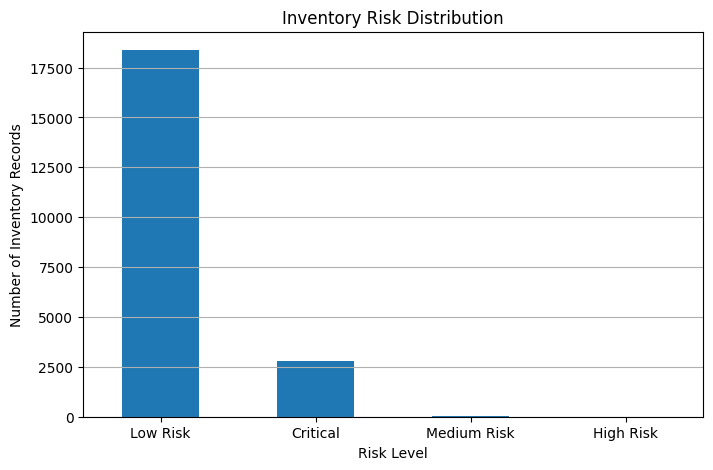

In [33]:
import matplotlib.pyplot as plt

risk_summary.plot(
    x='risk_level',
    y='count',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Inventory Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Inventory Records')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [34]:
store_risk = (
    inventory_df
    .groupby('store_id')
    .agg(
        total_inventory=('sku_id', 'count'),
        critical=('final_risk_level', lambda x: (x == 'Critical').sum()),
        high_risk=('final_risk_level', lambda x: (x == 'High Risk').sum()),
        medium_risk=('final_risk_level', lambda x: (x == 'Medium Risk').sum())
    )
    .sort_values('critical', ascending=False)
)

store_risk.head(10)

,total_inventory,critical,high_risk,medium_risk
store_id,,,,
ST03,747,107,0,0
ST10,730,106,0,1
ST24,695,105,1,0
ST12,712,103,0,0
ST22,695,101,0,2
ST07,695,99,0,2
ST04,711,99,0,3
ST27,690,99,0,0
ST01,720,98,1,1


In [35]:
import os

processed_path = r"C:\Users\Pawan\OneDrive\Desktop\Online-Retail-II\Online-retail-demand-forecasting\data1\processed"

os.makedirs(processed_path, exist_ok=True)

inventory_df.to_csv(
    os.path.join(processed_path, 'inventory_risk_scoring.csv'),
    index=False
)

print("Inventory risk dataset saved successfully.")
print("Rows:", len(inventory_df))

Inventory risk dataset saved successfully.
Rows: 21228


In [36]:
os.listdir(processed_path)

['inventory_risk_scoring.csv']